# Cleaning and grounding emerging science concepts: the concept classifier

This notebook is a runnable demo of the **concept-cleaning experiment** from the *emerging scientific concepts* study.
The experiment grounds the 426 candidate concepts of a frozen sample frame before they are used as nodes of an evolving
knowledge network. It trains three models:

1. **Concept classifier.** Is a noun phrase a real scientific concept? This is an L2 logistic regression on lexical + outcome-blind
   termhood + PCA(MiniLM) + PCA(SPECTER2) features, trained on D2 silver labels.
2. **Variant merger.** A pairwise LR decides whether two surface forms name the same concept (D3 + MeSH pairs).
3. **NIL-aware linker.** MiniLM nearest neighbour to OpenAlex / MeSH / Wikidata, with a calibrated threshold τ. Unlinked
   concepts are *kept* as nodes.

The full run (`method.py`) is a 16-step pipeline. It fetches arXiv titles, embeds ~1M strings on GPU, calls LLMs and hits
OpenAlex/Wikidata. None of that fits in a 10-minute notebook. So this demo re-runs the **core and primary model: step
`s3_classifier`**, with the original code, on a curated subset of **100 D2 phrases (70 train / 30 test)**. The features
were precomputed with the original feature code (`s1_corpus`, `s2_features`, `encoders.py`) and ship in `mini_demo_data.json`.

**Full-run headline (1,200 train / 300 test):** D2 test F1 0.818 [0.772, 0.859], AUC 0.888. This is +0.10 F1 over C-value
and +0.045 over LLM-B, but −0.08 below LLM-A, which co-produced the silver labels (circular).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is NOT pre-installed on Colab: always install
_pip('loguru==0.7.3')

# numpy, pandas, sklearn, scipy, matplotlib: pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
This is the original import block of `src/s3_classifier.py` and `src/clfdata.py`. The `common` and `featlib` imports that read the
on-disk caches are replaced by the data-backed cells below. `joblib` is dropped because the demo writes no model files.

In [2]:
from __future__ import annotations

import hashlib
import itertools
import json
import re
import time
import unicodedata
from collections import Counter

import matplotlib
import numpy as np
import pandas as pd
from loguru import logger
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score, brier_score_loss, cohen_kappa_score,
                             confusion_matrix, f1_score, roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

## Data loading
The loader tries the GitHub copy of `mini_demo_data.json` first and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-2/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(len(data["examples"]), "examples;", Counter((e["metadata_fold"], e["output"]) for e in data["examples"]))

100 D2 silver-labelled phrases (70 train / 30 test, stratified by label x macro-domain) with the exact classifier features of the concept-cleaning experiment: lexical (spaCy POS + wordfreq), outcome-blind termhood, MiniLM (384-d) and SPECTER2 (768-d, proximity adapter) L2-normalised embeddings of the normalised key.
100 examples; Counter({('train', 'CONCEPT'): 43, ('train', 'NOT_CONCEPT'): 22, ('test', 'CONCEPT'): 14, ('test', 'NOT_CONCEPT'): 11, ('train', 'TOO_GENERIC'): 5, ('test', 'TOO_GENERIC'): 5})


## Configuration
All tunable parameters are set here. The values are chosen so the demo runs in a few minutes on a CPU. The original values
are in the comments.

* `N_TRAIN` / `N_TEST`: how many of the 70 / 30 demo phrases to use (original 1,200 / 300 D2 phrases).
* `C_GRID`, `CW_GRID`, `PCA_GRID`: LR tuning grid. `PCA_GRID` must be `<=` the number of training rows in a CV fold, so the
  original 64 components are reduced for the 70-phrase demo.
* `N_SPLITS`: grouped CV folds. `N_BOOT`: bootstrap resamples for the 95% CIs.
* `RUN_ABLATIONS` / `RUN_HGB`: whether to run the feature-block ablations and the gradient-boosting comparison.

In [5]:
SEED = 20261001
N_TRAIN = 70          # original: 1200 (all D2-train rows);  demo max 70
N_TEST = 30            # original: 300  (all D2-test rows);   demo max 30
C_GRID = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]      # original: [0.01, 0.03, 0.1, 0.3, 1, 3, 10]
CW_GRID = [None, "balanced"]     # original: [None, "balanced"]
PCA_GRID = [32, None]    # original: [64, None]  (64 PCA components need > 64 rows per CV fold)
N_SPLITS = 5         # original: 5
N_BOOT = 2000         # original: 2000
RUN_ABLATIONS = True  # original: True
RUN_HGB = True        # original: True
HGB_PCA = 32          # original: 64 (PCA components per embedding block for the HGB comparison)
MINI = False

## Pipeline overview (`method.py`)
`method.py` is the artifact's entry point. It only runs the step scripts in `src/`, in order, each as a subprocess. The
original code is below. `main()` is **not** called here, because the step scripts and their multi-GB inputs are not in the
notebook. The cells after this one re-run step **`s3_classifier`** inline.

In [6]:
import argparse, os, subprocess, sys

STEPS = [("s0_load", []), ("s1a_fetch_arxiv", []), ("s1_corpus", []), ("t1_reused_code", []), ("s2_features", []),
         ("s3_classifier", []), ("s4_merger", []), ("s4b_merger_choice", []), ("s5_link_calib", []), ("s7a_predict", []),
         ("s6_llm_audit", []), ("s7b_merge_link", []), ("s6_llm_audit", ["--links"]), ("s8_freeze", []), ("s9_report", []), ("t3_leakage_checks", [])]


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--mini", action="store_true", help="T2 mini pipeline (no LLM spend, outputs in mini_run/)")
    ap.add_argument("--from", dest="start", default=None, help="first step to run (e.g. s3_classifier)")
    args = ap.parse_args()
    env = dict(os.environ)
    if args.mini:
        env["AII_MINI"] = "1"
    started = args.start is None
    for name, extra in STEPS:
        if not started:
            started = name == args.start
            if not started:
                continue
        if args.mini and name in ("s0_load", "s1a_fetch_arxiv", "t1_reused_code"):
            continue  # inputs are shared with the full run
        cmd = [sys.executable, str(ROOT / "src" / f"{name}.py")] + extra
        if args.mini and name == "s6_llm_audit":
            cmd.append("--dry-run")
        t0 = time.time()
        print(f"=== {name} {' '.join(extra)}", flush=True)
        r = subprocess.run(cmd, cwd=ROOT, env=env)
        print(f"=== {name} exit {r.returncode} in {time.time() - t0:.0f}s", flush=True)
        if r.returncode != 0:
            sys.exit(r.returncode)

# main() would run every step as `python src/<step>.py`; here we only print the order
for name, extra in STEPS:
    print(name, *extra)

s0_load
s1a_fetch_arxiv
s1_corpus
t1_reused_code
s2_features
s3_classifier
s4_merger
s4b_merger_choice
s5_link_calib
s7a_predict
s6_llm_audit
s7b_merge_link
s6_llm_audit --links
s8_freeze
s9_report
t3_leakage_checks


## Text normalisation (`src/vendor/textnorm.py`)
Phrase keys are normalised before any comparison. The steps are NFKC, Greek letters spelled out, lower case, hyphens to spaces,
British to American spelling, and a singular head noun. `s3` uses `normalise` for its train/test leakage assertion. These lines
are copied verbatim.

In [7]:
import re
import unicodedata

GREEK = {"α": "alpha", "β": "beta", "γ": "gamma", "δ": "delta", "ε": "epsilon", "ζ": "zeta", "η": "eta",
         "θ": "theta", "κ": "kappa", "λ": "lambda", "μ": "mu", "ν": "nu", "ξ": "xi", "π": "pi", "ρ": "rho",
         "σ": "sigma", "τ": "tau", "φ": "phi", "χ": "chi", "ψ": "psi", "ω": "omega", "Δ": "delta",
         "Γ": "gamma", "Ω": "omega", "Φ": "phi", "Ψ": "psi", "Σ": "sigma", "Λ": "lambda", "Θ": "theta"}
BRIT = {"tumour": "tumor", "behaviour": "behavior", "colour": "color", "haemoglobin": "hemoglobin",
        "anaemia": "anemia", "oestrogen": "estrogen", "paediatric": "pediatric", "optimisation": "optimization",
        "modelling": "modeling", "characterisation": "characterization", "organisation": "organization",
        "localisation": "localization", "stabilisation": "stabilization", "polarisation": "polarization",
        "haemorrhage": "hemorrhage", "leukaemia": "leukemia", "oesophageal": "esophageal", "fibre": "fiber",
        "centre": "center", "aluminium": "aluminum", "sulphur": "sulfur", "sulphate": "sulfate",
        "analyse": "analyze", "ageing": "aging", "labour": "labor", "neighbour": "neighbor",
        "haematopoietic": "hematopoietic", "anaesthesia": "anesthesia", "ischaemic": "ischemic",
        "oedema": "edema", "foetal": "fetal", "caesarean": "cesarean", "programme": "program"}
UNIT_RE = re.compile(r"^(\d+([.,]\d+)?|[a-z]?\d+[a-z]{0,3}|mg|kg|ml|mm|cm|nm|μm|km|hz|khz|mhz|ghz|kda|ppm|%|°c|°)$", re.I)
HYPHEN_RE = re.compile(r"[‐-―−/_]+|-")
SPACE_RE = re.compile(r"\s+")
NONWORD_EDGE = re.compile(r"^[^\w]+|[^\w+)\]]+$")


def plural_to_singular(w: str) -> str:
    """Tiny rule-based singulariser for the head token (keeps keys deterministic across processes)."""
    if len(w) <= 3 or not w.isalpha():
        return w
    if w.endswith(("ss", "us", "is", "ics", "sis", "xis")):
        return w
    if w.endswith("ies") and len(w) > 4:
        return w[:-3] + "y"
    if w.endswith(("ches", "shes", "xes", "zes", "sses")):
        return w[:-2]
    if w.endswith("s") and not w.endswith("ss"):
        return w[:-1]
    return w


def normalise(surface: str) -> str:
    s = unicodedata.normalize("NFKC", surface)
    for g, name in GREEK.items():
        if g in s:
            s = s.replace(g, f" {name} ")
    s = s.lower()
    s = HYPHEN_RE.sub(" ", s)
    s = s.replace("'s ", " ").replace("’s ", " ")
    s = re.sub(r"[\"“”‘’`,;:!?]", " ", s)
    s = SPACE_RE.sub(" ", s).strip()
    toks = [BRIT.get(t, t) for t in s.split(" ") if t]
    if not toks:
        return ""
    toks[-1] = plural_to_singular(toks[-1])
    return " ".join(toks)

## Feature matrix (`src/clfdata.py`: `FeatureSource`)
Each phrase gets 4 feature blocks:
* **lex** (45): token and character counts, stop-word share, POS of the first and last token, acronym, digit and Greek flags,
  wordfreq Zipf scores, generic-head flag, and a one-hot POS pattern (vocabulary fitted on D2-train only).
* **th** (11): *outcome-blind termhood* from a 1.48M-title arXiv corpus (≤ 2018) plus D1 abstracts. The features are log
  frequency, document frequency, C-value, left/right branching entropy, extension shares, and a missing flag.
* **mini** (384) / **spec** (768): L2-normalised MiniLM and SPECTER2 (proximity adapter) embeddings of the normalised key.

The original `FeatureSource` reads these blocks from `cache/lexical.parquet`, `cache/termhood.pkl` and `cache/emb/*.npy`.
Here the same arrays come from `data`. `build()` keeps the original block order and column names. Context embeddings
(`ctx`) are not shipped, so `self.ctx = None`, just as in the original when `minilm_ctx.npy` is absent. The
`full_plus_context` ablation is therefore skipped.

In [8]:
TH_NAMES = ["th_log_f", "th_src_ratio", "th_log_df", "th_cvalue", "th_right_entropy", "th_left_entropy",
            "th_share_right_ext_noun", "th_share_left_ext_adj_noun", "th_max_right_ext_share", "th_right_boundary_share",
            "th_missing"]
assert TH_NAMES == data["termhood_names"]


class FeatureSource:
    """Demo version: the lexical / termhood / embedding arrays come from mini_demo_data.json instead of cache files."""

    def __init__(self, with_ctx: bool = True) -> None:
        self.lex_names = data["lexical_names"]
        self.rows = {e["key"]: e for e in data["examples"]}
        self.ctx = None  # context embeddings are not part of the demo data

    def build(self, items: list[dict]) -> tuple[np.ndarray, dict[str, list[int]], list[str]]:
        """items: {ns, id, th_qid, text, ctx_key}. Returns X, block -> column indices, column names."""
        L = np.array([self.rows[it["id"]]["lexical"] for it in items], dtype=np.float32)
        T = np.array([self.rows[it["id"]]["termhood"] for it in items], dtype=np.float32)
        M = np.array([self.rows[it["id"]]["emb_minilm"] for it in items], dtype=np.float32)
        S = np.array([self.rows[it["id"]]["emb_specter2"] for it in items], dtype=np.float32)
        blocks_arr = [L, T, M, S]
        names = list(self.lex_names) + TH_NAMES + [f"mini_{i}" for i in range(M.shape[1])] + [f"spec_{i}" for i in range(S.shape[1])]
        X = np.concatenate(blocks_arr, axis=1)
        o = 0
        blocks = {}
        for b, arr in zip(["lex", "th", "mini", "spec", "ctx", "ctxflag"], blocks_arr):
            blocks[b] = list(range(o, o + arr.shape[1]))
            o += arr.shape[1]
        return X, blocks, names

## Model pipeline and metrics (`src/clfdata.py`, verbatim)
`make_pipeline` builds a `ColumnTransformer`. It standardises the tabular blocks and applies PCA then standardisation to each
embedding block, followed by an L2 logistic regression (or HGB). The metric helpers compute point estimates, percentile
bootstrap CIs, paired-bootstrap differences, and the two frozen thresholds: **t_F1** (argmax out-of-fold F1) and **t_P90**
(smallest threshold with out-of-fold precision ≥ 0.90). The only change is `boot_idx`, whose default resample count is
now `N_BOOT` from the config cell.

In [9]:
def make_pipeline(blocks: dict[str, list[int]], use: list[str], *, pca: int | None, model: str = "lr", C: float = 1.0,
                  class_weight=None, hgb: dict | None = None, multinomial: bool = False) -> Pipeline:
    tr = []
    tab = [c for b in use if b in ("lex", "th", "ctxflag") for c in blocks[b]]
    if tab:
        tr.append(("tab", StandardScaler(), tab))
    for b in use:
        if b in ("mini", "spec", "ctx"):
            n = pca if pca else None
            if n:
                tr.append((b, Pipeline([("pca", PCA(n_components=n, random_state=SEED)), ("sc", StandardScaler())]), blocks[b]))
            else:
                tr.append((b, StandardScaler(), blocks[b]))
    ct = ColumnTransformer(tr, remainder="drop")
    if model == "lr":
        clf = LogisticRegression(C=C, class_weight=class_weight, max_iter=5000, solver="lbfgs")
    else:
        clf = HistGradientBoostingClassifier(random_state=SEED, **(hgb or {}))
    return Pipeline([("ct", ct), ("clf", clf)])


# ------------------------------------------------------------------ metrics
def _prf(y: np.ndarray, yhat: np.ndarray) -> tuple[float, float, float]:
    tp = float(((y == 1) & (yhat == 1)).sum())
    fp = float(((y == 0) & (yhat == 1)).sum())
    fn = float(((y == 1) & (yhat == 0)).sum())
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return p, r, f


def point_metrics(y: np.ndarray, p: np.ndarray | None, yhat: np.ndarray) -> dict:
    P, R, F = _prf(y, yhat)
    out = {"n": int(len(y)), "n_pos": int(y.sum()), "precision": P, "recall": R, "f1": F,
           "accuracy": float((y == yhat).mean()), "balanced_accuracy": float(balanced_accuracy_score(y, yhat)),
           "kappa": float(cohen_kappa_score(y, yhat)) if len(set(y)) > 1 or len(set(yhat)) > 1 else 0.0}
    if p is not None and len(set(y)) > 1:
        out["auc"] = float(roc_auc_score(y, p))
        out["auprc"] = float(average_precision_score(y, p))
        out["brier"] = float(brier_score_loss(y, np.clip(p, 0, 1)))
    return out


def boot_idx(n: int, reps: int = N_BOOT, seed: int = SEED) -> np.ndarray:
    return np.random.default_rng(seed).integers(0, n, size=(reps, n))


def boot_metrics(y: np.ndarray, p: np.ndarray | None, yhat: np.ndarray, idx: np.ndarray | None = None,
                 keys=("precision", "recall", "f1", "accuracy", "auc", "auprc", "brier", "balanced_accuracy", "kappa")) -> dict:
    idx = boot_idx(len(y)) if idx is None else idx
    res: dict[str, list[float]] = {k: [] for k in keys}
    def put(k, v):
        if k in res:
            res[k].append(v)
    for b in idx:
        yb, hb = y[b], yhat[b]
        P, R, F = _prf(yb, hb)
        put("precision", P)
        put("recall", R)
        put("f1", F)
        put("accuracy", float((yb == hb).mean()))
        if len(set(yb)) > 1:
            if "balanced_accuracy" in res:
                put("balanced_accuracy", float(balanced_accuracy_score(yb, hb)))
            if "kappa" in res:
                put("kappa", float(cohen_kappa_score(yb, hb)))
            if p is not None:
                pb = p[b]
                if "auc" in res:
                    put("auc", float(roc_auc_score(yb, pb)))
                if "auprc" in res:
                    put("auprc", float(average_precision_score(yb, pb)))
                if "brier" in res:
                    put("brier", float(brier_score_loss(yb, np.clip(pb, 0, 1))))
    pt = point_metrics(y, p, yhat)
    out = {}
    for k, v in res.items():
        if v and k in pt:
            out[k] = {"point": pt[k], "ci95": [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))]}
    out["n"] = pt["n"]
    out["n_pos"] = pt["n_pos"]
    return out


def paired_diff(y: np.ndarray, pa: np.ndarray, ha: np.ndarray, pb: np.ndarray | None, hb: np.ndarray,
                idx: np.ndarray | None = None) -> dict:
    """Paired bootstrap of F1 and AUC differences (model a minus model b) on the same resamples."""
    idx = boot_idx(len(y)) if idx is None else idx
    df1, dauc = [], []
    for b in idx:
        yb = y[b]
        df1.append(_prf(yb, ha[b])[2] - _prf(yb, hb[b])[2])
        if len(set(yb)) > 1 and pb is not None:
            dauc.append(roc_auc_score(yb, pa[b]) - roc_auc_score(yb, pb[b]))
    out = {"f1_diff": {"point": _prf(y, ha)[2] - _prf(y, hb)[2],
                       "ci95": [float(np.percentile(df1, 2.5)), float(np.percentile(df1, 97.5))],
                       "p_le_0": float(np.mean(np.array(df1) <= 0))}}
    if dauc:
        out["auc_diff"] = {"point": float(roc_auc_score(y, pa) - roc_auc_score(y, pb)),
                           "ci95": [float(np.percentile(dauc, 2.5)), float(np.percentile(dauc, 97.5))],
                           "p_le_0": float(np.mean(np.array(dauc) <= 0))}
    return out


def best_f1_threshold(y: np.ndarray, p: np.ndarray) -> tuple[float, float]:
    best = (0.5, -1.0)
    for t in np.unique(np.round(p, 4)):
        f = _prf(y, (p >= t).astype(int))[2]
        if f > best[1]:
            best = (float(t), f)
    return best


def precision_threshold(y: np.ndarray, p: np.ndarray, target: float) -> float | None:
    """Smallest threshold with precision >= target (on the given out-of-fold scores)."""
    for t in np.sort(np.unique(np.round(p, 4))):
        yh = (p >= t).astype(int)
        if yh.sum() == 0:
            break
        if _prf(y, yh)[0] >= target:
            return float(t)
    return None

## Cross-validation and tuning (`src/s3_classifier.py`, verbatim)
Tuning uses **train only**, with `StratifiedGroupKFold` grouped by the D2 variant cluster so that surface variants of one concept
never straddle folds. The selection criterion is the mean per-fold F1 at 0.5. The out-of-fold probabilities of the winning
configuration then set the thresholds. The grids come from the config cell, `n_splits` defaults to `N_SPLITS`, and the HGB PCA size (64 in the original) is `HGB_PCA`.

In [10]:
FULL = ["lex", "th", "mini", "spec"]
ABLATIONS = {"no_termhood": ["lex", "mini", "spec"], "no_embeddings": ["lex", "th"], "lexical_only": ["lex"],
             "minilm_only": ["mini"], "specter2_only": ["spec"], "full_plus_context": FULL + ["ctx", "ctxflag"]}


def groups_for(rows: list[dict]) -> np.ndarray:
    g = []
    for i, r in enumerate(rows):
        c = r.get("metadata_variant_cluster")
        g.append(str(c) if c is not None else f"solo_{i}")
    return np.array(g)


FOLDS: dict = {}


def oof_proba(make, X, y, groups, n_splits=N_SPLITS) -> np.ndarray:
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    p = np.zeros(len(y))
    fold = np.zeros(len(y), dtype=int)
    for k, (tr, va) in enumerate(cv.split(X, y, groups)):
        m = make()
        m.fit(X[tr], y[tr])
        p[va] = m.predict_proba(X[va])[:, 1]
        fold[va] = k
    FOLDS["last"] = fold
    return p


def mean_fold_f1(y, p, thr=0.5) -> float:
    fold = FOLDS["last"]
    return float(np.mean([f1_score(y[fold == k], (p[fold == k] >= thr).astype(int)) for k in np.unique(fold)]))


def tune_lr(X, y, groups, blocks, use, grid_pca=PCA_GRID) -> tuple[dict, list[dict], np.ndarray]:
    results = []
    best = None
    for C, cw, pca in itertools.product(C_GRID, CW_GRID, grid_pca):
        if not any(b in ("mini", "spec", "ctx") for b in use) and pca is not None:
            continue
        mk = lambda C=C, cw=cw, pca=pca: make_pipeline(blocks, use, pca=pca, C=C, class_weight=cw)
        p = oof_proba(mk, X, y, groups)
        f1 = mean_fold_f1(y, p)  # selection criterion: mean OOF F1 over the 5 folds (at 0.5)
        r = {"C": C, "class_weight": cw, "pca": pca, "oof_f1_at_0.5": f1, "oof_best_thr_f1": best_f1_threshold(y, p)[1],
             "oof_auc": float(point_metrics(y, p, (p >= 0.5).astype(int)).get("auc", np.nan))}
        results.append(r)
        if best is None or r["oof_f1_at_0.5"] > best[0]["oof_f1_at_0.5"]:
            best = (r, p)
    return best[0], results, best[1]


def tune_hgb(X, y, groups, blocks, use) -> tuple[dict, list[dict], np.ndarray]:
    results, best = [], None
    for lr, leaves, l2 in itertools.product([0.05, 0.1], [15, 31], [0.0, 1.0]):
        hp = {"learning_rate": lr, "max_leaf_nodes": leaves, "l2_regularization": l2, "max_iter": 300,
              "early_stopping": False}
        mk = lambda hp=hp: make_pipeline(blocks, use, pca=HGB_PCA, model="hgb", hgb=hp)
        p = oof_proba(mk, X, y, groups)
        f1 = mean_fold_f1(y, p)
        r = {**hp, "oof_f1_at_0.5": f1, "oof_best_thr_f1": best_f1_threshold(y, p)[1]}
        results.append(r)
        if best is None or f1 > best[0]["oof_f1_at_0.5"]:
            best = (r, p)
    return best[0], results, best[1]

## Step 1: Train/test rows and the leakage guard
D2 rows labelled `UNRESOLVED` (LLM A and B disagreed and no adjudication was made) are dropped. The assertion checks that no
normalised key or surface form occurs in both train and test.

In [11]:
t0 = time.time()
d2 = data["examples"]
tr_rows = [r for r in d2 if r["metadata_fold"] == "train" and r["output"] != "UNRESOLVED"][:N_TRAIN]
te_rows = [r for r in d2 if r["metadata_fold"] == "test" and r["output"] != "UNRESOLVED"][:N_TEST]
n_unres = sum(r["output"] == "UNRESOLVED" for r in d2 if r["metadata_fold"] in ("train", "test"))
logger.info(f"train {len(tr_rows)} {Counter(r['output'] for r in tr_rows)}; test {len(te_rows)} "
            f"{Counter(r['output'] for r in te_rows)}; dropped UNRESOLVED {n_unres}")
# leakage assert: no normalised key shared between train and test
k_tr = {normalise(r["key"]) for r in tr_rows} | {normalise(s) for r in tr_rows for s in r["surface_forms"]}
k_te = {normalise(r["key"]) for r in te_rows} | {normalise(s) for r in te_rows for s in r["surface_forms"]}
overlap = k_tr & k_te
assert len(overlap) == 0 or MINI, f"D2 train/test key overlap: {list(overlap)[:5]}"

2026-09-29 12:15:35.405 | INFO     | __main__:<module>:6 - train 70 Counter({'CONCEPT': 43, 'NOT_CONCEPT': 22, 'TOO_GENERIC': 5}); test 30 Counter({'CONCEPT': 14, 'NOT_CONCEPT': 11, 'TOO_GENERIC': 5}); dropped UNRESOLVED 0


## Step 2: Build the feature matrices
TRAIN and TEST use the same code path. The binary target is `CONCEPT`; `NOT_CONCEPT` and `TOO_GENERIC` count as negatives.

In [12]:
fs = FeatureSource()

def items_d2(rows):
    return [{"ns": "d2", "id": r["key"], "th_qid": f"d2:{r['key']}", "text": r["key"], "ctx_key": f"d2:{r['key']}"} for r in rows]

Xtr, blocks, names = fs.build(items_d2(tr_rows))
Xte, _, _ = fs.build(items_d2(te_rows))
ytr = np.array([r["output"] == "CONCEPT" for r in tr_rows], dtype=int)
yte = np.array([r["output"] == "CONCEPT" for r in te_rows], dtype=int)
gtr = groups_for(tr_rows)
logger.info(f"X train {Xtr.shape}, blocks { {k: len(v) for k, v in blocks.items()} }")

2026-09-29 12:15:35.415 | INFO     | __main__:<module>:11 - X train (70, 1208), blocks {'lex': 45, 'th': 11, 'mini': 384, 'spec': 768}


## Step 3: Primary model tuning and threshold freezing
The C × class_weight × PCA grid is searched on train folds only. The best configuration is refit on all training rows, and
**t_F1** and **t_P90** are frozen from its out-of-fold probabilities *before* the test rows are scored. In the original, the
model and `thresholds.json` are written to `models/`. Here they stay in memory.

In [13]:
best, grid, p_oof = tune_lr(Xtr, ytr, gtr, blocks, FULL)
logger.info(f"PRIMARY best config {best} ({time.time() - t0:.0f}s)")
t_f1, oof_f1 = best_f1_threshold(ytr, p_oof)
t_p90 = precision_threshold(ytr, p_oof, 0.90)
primary = make_pipeline(blocks, FULL, pca=best["pca"], C=best["C"], class_weight=best["class_weight"])
primary.fit(Xtr, ytr)
thresholds = {"t_F1": t_f1, "oof_f1_at_t_F1": oof_f1, "t_P90": t_p90,
              "t_P90_note": "smallest t with OOF precision >= 0.90" if t_p90 is not None else "precision 0.90 never reached; STRICT uses max OOF prob",
              "config": best, "frozen_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())}
if t_p90 is None:
    thresholds["t_P90"] = float(np.max(p_oof))
logger.info(f"thresholds frozen: {thresholds}")

2026-09-29 12:15:41.155 | INFO     | __main__:<module>:2 - PRIMARY best config {'C': 3, 'class_weight': 'balanced', 'pca': 32, 'oof_f1_at_0.5': 0.8083725490196079, 'oof_best_thr_f1': 0.8163265306122448, 'oof_auc': 0.8423772609819121} (6s)


2026-09-29 12:15:41.219 | INFO     | __main__:<module>:12 - thresholds frozen: {'t_F1': 0.2316, 'oof_f1_at_t_F1': 0.8163265306122448, 't_P90': 0.7963, 't_P90_note': 'smallest t with OOF precision >= 0.90', 'config': {'C': 3, 'class_weight': 'balanced', 'pca': 32, 'oof_f1_at_0.5': 0.8083725490196079, 'oof_best_thr_f1': 0.8163265306122448, 'oof_auc': 0.8423772609819121}, 'frozen_utc': '2026-09-29T12:15:41Z'}


## Step 4: Comparisons (feature-block ablations and HGB) and baselines
Each ablation drops feature blocks and is tuned with the same CV. For example, `no_termhood` produces the −termhood
sensitivity column of the frozen population. A HistGradientBoosting model on the full feature set is the non-linear comparison.
The **C-value** baseline is a single threshold on the termhood C-value, tuned on train.

In [14]:
comp: dict = {}
oofs = {"primary": p_oof}
for name, use in (ABLATIONS.items() if RUN_ABLATIONS else []):
    if "ctx" in use and fs.ctx is None:
        continue
    b, _, p = tune_lr(Xtr, ytr, gtr, blocks, use)
    tt, _ = best_f1_threshold(ytr, p)
    m = make_pipeline(blocks, use, pca=b["pca"], C=b["C"], class_weight=b["class_weight"]).fit(Xtr, ytr)
    comp[name] = {"config": b, "t_F1": tt, "model": m, "use": use}
    oofs[name] = p
    logger.info(f"ablation {name}: {b}")
hgrid = []
if RUN_HGB:
    hb, hgrid, hp = tune_hgb(Xtr, ytr, gtr, blocks, FULL)
    ht, _ = best_f1_threshold(ytr, hp)
    hm = make_pipeline(blocks, FULL, pca=HGB_PCA, model="hgb", hgb={k: hb[k] for k in ("learning_rate", "max_leaf_nodes", "l2_regularization", "max_iter", "early_stopping")}).fit(Xtr, ytr)
    comp["hgb"] = {"config": hb, "t_F1": ht, "model": hm, "use": FULL}
    oofs["hgb"] = hp
# best CV comparison model (F4 sensitivity column): highest OOF best-threshold F1 among comparisons
cv_scores = {k: best_f1_threshold(ytr, v)[1] for k, v in oofs.items() if k != "primary" and k != "full_plus_context"}
best_comp = max(cv_scores, key=cv_scores.get) if cv_scores else None
logger.info(f"best CV comparison: {best_comp}")

# ---------------- baselines tuned on train OOF
th_idx = names.index("th_cvalue")
cv_tr = Xtr[:, th_idx]
t_cv, _ = best_f1_threshold(ytr, cv_tr)

2026-09-29 12:15:46.365 | INFO     | __main__:<module>:11 - ablation no_termhood: {'C': 1, 'class_weight': 'balanced', 'pca': 32, 'oof_f1_at_0.5': 0.77893566791265, 'oof_best_thr_f1': 0.8124999999999999, 'oof_auc': 0.8096468561584841}


2026-09-29 12:15:46.886 | INFO     | __main__:<module>:11 - ablation no_embeddings: {'C': 0.01, 'class_weight': 'balanced', 'pca': None, 'oof_f1_at_0.5': 0.7855921855921856, 'oof_best_thr_f1': 0.8045977011494252, 'oof_auc': 0.7527993109388459}


2026-09-29 12:15:47.369 | INFO     | __main__:<module>:11 - ablation lexical_only: {'C': 0.01, 'class_weight': None, 'pca': None, 'oof_f1_at_0.5': 0.7468514094601051, 'oof_best_thr_f1': 0.7678571428571428, 'oof_auc': 0.570198105081826}


2026-09-29 12:15:48.660 | INFO     | __main__:<module>:11 - ablation minilm_only: {'C': 0.1, 'class_weight': None, 'pca': None, 'oof_f1_at_0.5': 0.7695906432748537, 'oof_best_thr_f1': 0.7959183673469388, 'oof_auc': 0.7502153316106804}


2026-09-29 12:15:54.459 | INFO     | __main__:<module>:11 - ablation specter2_only: {'C': 0.1, 'class_weight': None, 'pca': 32, 'oof_f1_at_0.5': 0.7712659846547314, 'oof_best_thr_f1': 0.8080808080808081, 'oof_auc': 0.7149009474590869}


2026-09-29 12:16:02.863 | INFO     | __main__:<module>:22 - best CV comparison: no_termhood


## Step 5: Test evaluation, done once
The frozen primary model is scored on the held-out test rows at t_F1 (and at t_P90 for the STRICT population). Every comparison
and baseline is evaluated on the **same bootstrap resamples**, so the paired differences are valid. The LLM-A
(gemini-2.5-flash-lite) and LLM-B (gpt-4.1-nano) baselines helped create the silver labels, so they are circular and optimistic.

In [15]:
p_te = primary.predict_proba(Xte)[:, 1]
h_te = (p_te >= t_f1).astype(int)
h_te_strict = (p_te >= thresholds["t_P90"]).astype(int)
idx = boot_idx(len(yte))
res: dict = {"n_train": len(ytr), "n_test": len(yte), "train_label_counts": dict(Counter(r["output"] for r in tr_rows)),
             "test_label_counts": dict(Counter(r["output"] for r in te_rows)), "dropped_unresolved": n_unres,
             "train_test_key_overlap": len(overlap), "primary_config": best, "thresholds": thresholds,
             "cv_grid_primary": grid, "hgb_grid": hgrid}
res["test_primary_tF1"] = boot_metrics(yte, p_te, h_te, idx)
res["test_primary_tP90"] = boot_metrics(yte, p_te, h_te_strict, idx)
res["confusion_primary_tF1"] = confusion_matrix(yte, h_te).tolist()
# comparisons
res["test_comparisons"] = {}
for name, c in comp.items():
    pc = c["model"].predict_proba(Xte)[:, 1]
    hc = (pc >= c["t_F1"]).astype(int)
    res["test_comparisons"][name] = {"metrics": boot_metrics(yte, pc, hc, idx), "config": c["config"],
                                     "paired_primary_minus_this": paired_diff(yte, p_te, h_te, pc, hc, idx)}
# baselines
maj = int(ytr.mean() >= 0.5)
base = {"majority_class": (np.full(len(yte), 0.5), np.full(len(yte), maj)),
        "cvalue_threshold": (Xte[:, th_idx], (Xte[:, th_idx] >= t_cv).astype(int)),
        "llm_label_A": (None, np.array([r.get("metadata_label_A") == "CONCEPT" for r in te_rows], dtype=int)),
        "llm_label_B": (None, np.array([r.get("metadata_label_B") == "CONCEPT" for r in te_rows], dtype=int))}
res["test_baselines"] = {}
for name, (pb, hb_) in base.items():
    score = pb if pb is not None else hb_.astype(float)
    m = boot_metrics(yte, score if name != "majority_class" else None, hb_, idx)
    if name == "majority_class":
        m["auc"] = {"point": 0.5, "ci95": [0.5, 0.5]}
    res["test_baselines"][name] = {"metrics": m, "paired_primary_minus_this": paired_diff(yte, p_te, h_te, score, hb_, idx)}
res["test_baselines"]["cvalue_threshold"]["t"] = t_cv
logger.info(f"TEST primary: F1 {res['test_primary_tF1']['f1']} AUC {res['test_primary_tF1'].get('auc')}")

2026-09-29 12:16:47.761 | INFO     | __main__:<module>:33 - TEST primary: F1 {'point': 0.7058823529411764, 'ci95': [0.499621212121212, 0.8648648648648648]} AUC {'point': 0.7901785714285714, 'ci95': [0.6076261518695729, 0.9375]}


## Step 6: Reliability curve, per-domain metrics, and the secondary 3-class model
In the original, the reliability curve is saved to `results/fig_reliability.png`. Here it is drawn in the final cell. The
secondary model predicts `CONCEPT` / `NOT_CONCEPT` / `TOO_GENERIC`.

The original step also trains a D2 + D4a-augmented variant and scores the human anchors (SemEval-2017 / SciERC). Both need the
D4a dataset (~14 MB), which is not part of this demo. Full-run anchor results are E1 F1 0.674 (LLM-A 0.776) and E2 F1 0.706,
AUC 0.82.

In [16]:
fr, mp_ = calibration_curve(yte, p_te, n_bins=10, strategy="uniform")
res["reliability_curve"] = {"mean_predicted": mp_.tolist(), "fraction_positive": fr.tolist()}
# per macro-domain
res["per_macro_domain"] = {}
for dom in sorted({r.get("metadata_macro_domain") for r in te_rows}, key=str):
    ii = np.array([r.get("metadata_macro_domain") == dom for r in te_rows])
    if ii.sum() >= 5:
        res["per_macro_domain"][str(dom)] = point_metrics(yte[ii], p_te[ii] if len(set(yte[ii])) > 1 else None, h_te[ii])
# ---------------- SECONDARY 4-class
lab3 = {"CONCEPT": 0, "NOT_CONCEPT": 1, "TOO_GENERIC": 2}
y3tr = np.array([lab3.get(r["output"], 1) for r in tr_rows])
y3te = np.array([lab3.get(r["output"], 1) for r in te_rows])
m3 = make_pipeline(blocks, FULL, pca=best["pca"], C=best["C"], class_weight="balanced").fit(Xtr, y3tr)
pr3 = m3.predict(Xte)
res["secondary_3class"] = {"macro_f1": float(f1_score(y3te, pr3, average="macro")),
                           "per_class_f1": dict(zip(lab3, f1_score(y3te, pr3, average=None, labels=[0, 1, 2]).tolist())),
                           "confusion": confusion_matrix(y3te, pr3, labels=[0, 1, 2]).tolist(), "labels": list(lab3)}
res["runtime_s"] = time.time() - t0
print(json.dumps({k: res[k] for k in ("per_macro_domain", "secondary_3class", "runtime_s")}, indent=1, default=float))

{
 "per_macro_domain": {
  "computing_engineering": {
   "n": 5,
   "n_pos": 3,
   "precision": 0.6,
   "recall": 1.0,
   "f1": 0.7499999999999999,
   "accuracy": 0.6,
   "balanced_accuracy": 0.5,
   "kappa": 0.0,
   "auc": 0.5,
   "auprc": 0.7555555555555555,
   "brier": 0.31283006773988753
  },
  "health": {
   "n": 7,
   "n_pos": 3,
   "precision": 0.6,
   "recall": 1.0,
   "f1": 0.7499999999999999,
   "accuracy": 0.7142857142857143,
   "balanced_accuracy": 0.75,
   "kappa": 0.46153846153846156,
   "auc": 0.8333333333333334,
   "auprc": 0.8055555555555556,
   "brier": 0.1932488726545303
  },
  "life": {
   "n": 5,
   "n_pos": 3,
   "precision": 1.0,
   "recall": 0.6666666666666666,
   "f1": 0.8,
   "accuracy": 0.8,
   "balanced_accuracy": 0.8333333333333333,
   "kappa": 0.6153846153846154,
   "auc": 0.8333333333333333,
   "auprc": 0.9166666666666665,
   "brier": 0.19562521998904814
  },
  "physical": {
   "n": 6,
   "n_pos": 3,
   "precision": 0.5,
   "recall": 0.6666666666666666,
 

## Results
The table compares the demo's test metrics (primary model, comparisons, baselines) with the **full-run reference** stored in the
data file. The plots show (a) test F1 with bootstrap 95% CIs, (b) the reliability curve, and (c) the demo's P(CONCEPT)
against the full-run model's P(CONCEPT) for the same 30 test phrases. On 70 training rows the numbers are much noisier than
in the full run, so read them as a working demonstration of the procedure, not as a replication.

Demo: 70 train / 30 test phrases; best config {'C': 3, 'class_weight': 'balanced', 'pca': 32, 'oof_f1_at_0.5': 0.8083725490196079, 'oof_best_thr_f1': 0.8163265306122448, 'oof_auc': 0.8423772609819121}; t_F1=0.2316, t_P90=0.7963
                     model  precision  recall    f1   auc                                   f1_ci95
          PRIMARY LR @t_F1      0.600   0.857 0.706 0.790   [0.499621212121212, 0.8648648648648648]
         PRIMARY LR @t_P90      0.688   0.786 0.733 0.790  [0.5185185185185186, 0.8888888888888888]
   comparison: no_termhood      0.591   0.929 0.722 0.732  [0.5185185185185185, 0.8749999999999999]
 comparison: no_embeddings      0.667   0.714 0.690 0.835 [0.46653846153846157, 0.8571428571428572]
  comparison: lexical_only      0.467   1.000 0.636 0.812 [0.46052631578947373, 0.7755102040816326]
   comparison: minilm_only      0.565   0.929 0.703 0.804                 [0.5, 0.8571428571428571]
 comparison: specter2_only      0.421   0.571 0.485 0.500               

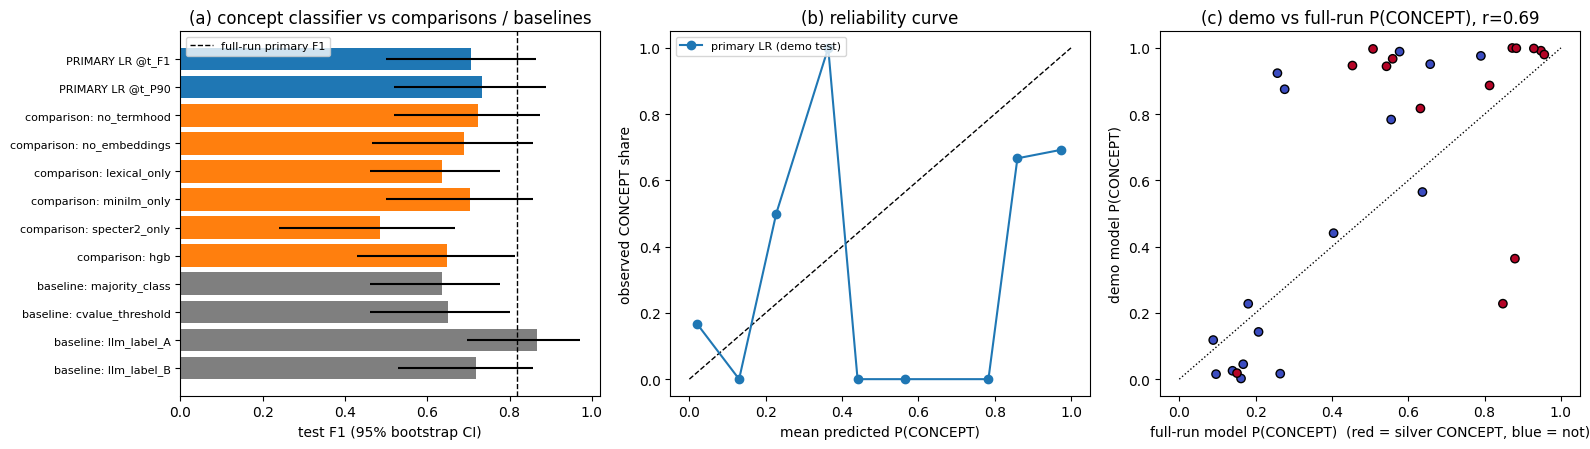


Test phrases sorted by demo P(CONCEPT):
                          phrase      silver  p_demo  accept@t_F1  p_full_run
          fuzzy logic controller     CONCEPT   1.000            1     0.87265
        safety management system     CONCEPT   0.999            1     0.88315
     cultured hippocampal neuron     CONCEPT   0.998            1     0.92910
                             yy1     CONCEPT   0.997            1     0.50767
nonalcoholic fatty liver disease     CONCEPT   0.992            1     0.94768
                      anova test TOO_GENERIC   0.989            1     0.57729
         gastric residual volume     CONCEPT   0.980            1     0.95647
            tracking performance NOT_CONCEPT   0.976            1     0.79030
                            su(3     CONCEPT   0.967            1     0.55916
      pure and applied chemistry NOT_CONCEPT   0.951            1     0.65751
               materials project     CONCEPT   0.947            1     0.45374
                     da

In [17]:
def row(name, m):
    g = lambda k: m.get(k, {}).get("point", float("nan")) if isinstance(m.get(k), dict) else float("nan")
    return {"model": name, "precision": g("precision"), "recall": g("recall"), "f1": g("f1"), "auc": g("auc"),
            "f1_ci95": m.get("f1", {}).get("ci95")}
rows_ = [row("PRIMARY LR @t_F1", res["test_primary_tF1"]), row("PRIMARY LR @t_P90", res["test_primary_tP90"])]
rows_ += [row(f"comparison: {k}", v["metrics"]) for k, v in res["test_comparisons"].items()]
rows_ += [row(f"baseline: {k}", v["metrics"]) for k, v in res["test_baselines"].items()]
tab = pd.DataFrame(rows_)
pd.set_option("display.width", 160)
print(f"Demo: {res['n_train']} train / {res['n_test']} test phrases; best config {best}; t_F1={t_f1:.4f}, t_P90={thresholds['t_P90']:.4f}")
print(tab.round(3).to_string(index=False))
ref = data["full_run_reference"]
print(f"\nFull-run reference ({ref['n_train']} train / {ref['n_test']} test):",
      {k: round(v["point"], 3) for k, v in ref["test_primary_tF1"].items()}, "thresholds", ref["thresholds"])
print("confusion (rows = true 0/1, cols = pred 0/1):", res["confusion_primary_tF1"])

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
t_ = tab.dropna(subset=["f1"])
lo = [f - ci[0] if ci else 0 for f, ci in zip(t_["f1"], t_["f1_ci95"])]
hi = [ci[1] - f if ci else 0 for f, ci in zip(t_["f1"], t_["f1_ci95"])]
cols = ["#1f77b4" if m.startswith("PRIMARY") else ("#ff7f0e" if m.startswith("comparison") else "#7f7f7f") for m in t_["model"]]
ax[0].barh(range(len(t_)), t_["f1"], xerr=[lo, hi], color=cols)
ax[0].set_yticks(range(len(t_)))
ax[0].set_yticklabels(t_["model"], fontsize=8)
ax[0].invert_yaxis()
ax[0].axvline(ref["test_primary_tF1"]["f1"]["point"], ls="--", c="k", lw=1, label="full-run primary F1")
ax[0].set_xlabel("test F1 (95% bootstrap CI)")
ax[0].legend(fontsize=8)
ax[0].set_title("(a) concept classifier vs comparisons / baselines")
ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].plot(mp_, fr, "o-", color="#1f77b4", label="primary LR (demo test)")
ax[1].set_xlabel("mean predicted P(CONCEPT)")
ax[1].set_ylabel("observed CONCEPT share")
ax[1].legend(loc="upper left", fontsize=8)
ax[1].set_title("(b) reliability curve")
fp = np.array([r.get("full_run_p_concept", np.nan) for r in te_rows])
ax[2].scatter(fp, p_te, c=yte, cmap="coolwarm", edgecolor="k")
ax[2].plot([0, 1], [0, 1], "k:", lw=1)
ok = ~np.isnan(fp)
if ok.sum() > 2:
    ax[2].set_title(f"(c) demo vs full-run P(CONCEPT), r={np.corrcoef(fp[ok], p_te[ok])[0, 1]:.2f}")
ax[2].set_xlabel("full-run model P(CONCEPT)  (red = silver CONCEPT, blue = not)")
ax[2].set_ylabel("demo model P(CONCEPT)")
plt.tight_layout()
plt.show()

print("\nTest phrases sorted by demo P(CONCEPT):")
ex = pd.DataFrame({"phrase": [r["key"] for r in te_rows], "silver": [r["output"] for r in te_rows],
                   "p_demo": p_te.round(3), "accept@t_F1": h_te, "p_full_run": fp})
print(ex.sort_values("p_demo", ascending=False).to_string(index=False))